# 05_Main_1D_CNN_SER - Main Speech Emotion Recognition Model

Notebook này là bước tiếp theo sau `04_Baseline_Models`.

Mục tiêu của 04 là tạo mốc classical ML bằng MFCC statistical vector + SVM/RF/LogReg. Mục tiêu của 05 là chuyển sang **frame-level feature sequence + 1D-CNN**, để model học pattern theo thời gian thay vì chỉ dùng mean/std pooling.

| Nguồn tham khảo | Ý tưởng đưa vào notebook |
|---|---|
| IEEE/CEUR 1D-CNN trên RAVDESS + CREMA-D + TESS + SAVEE | 1D-CNN với MFCC, ZCR, energy, entropy of energy, RMS |
| MDPI 2022 về CNN trên nhiều SER datasets | Báo cáo cả random split và strict split để tránh overclaim |
| Real-time SER + augmentation | Augmentation nhẹ trên train: noise, gain, time shift, time masking |
| emotion2vec / SSL SER | Để future work sau khi có CNN baseline/main model ổn |

Notebook ưu tiên chạy được trên Kaggle/Colab với tài nguyên vừa phải.

## 1. Experimental Design

Notebook 05 gồm ba ý chính:

1. **Sequence representation**: mỗi audio thành ma trận `(time_frames, feature_dim)`.
2. **1D-CNN main model**: convolution theo trục thời gian để học dynamics của emotion.
3. **Ablation nhỏ**: so sánh `mfcc`, `mfcc_delta`, và `full` feature fusion.

Hai protocol giữ giống notebook 04:

| Protocol | Ý nghĩa |
|---|---|
| `paper_comparable_random` | Chia random theo file, dễ so với nhiều paper/Kaggle |
| `strict_speaker_aware` | Dùng split nghiêm hơn từ preprocessing, phản ánh speaker/domain shift |

Metric chính là **macro-F1**.

## 1.1. Main Model References and Comparison

Notebook 05 không chỉ đổi từ SVM sang CNN, mà đổi cả **representation**: từ vector thống kê sang chuỗi đặc trưng theo thời gian. Bảng dưới đây tóm tắt các hướng chính được dùng để thiết kế notebook.

| Reference / group | Dataset | Model họ dùng | Điểm hay có thể học | Notebook 05 kế thừa gì |
|---|---|---|---|---|
| Ullah et al. / IEEE, được CEUR review trích lại | CREMA-D + RAVDESS + SAVEE + TESS | 1D-CNN với ZCR, energy, entropy of energy, RMS, MFCC | Feature fusion sát với 4-dataset setup | Dùng 1D-CNN trên frame-level MFCC + acoustic features |
| MDPI 2022, CNN on different SER datasets | CREMA-D + RAVDESS + SAVEE + TESS | CNN/ResNet trên spectrogram | Chứng minh proper split thấp hơn random split nhiều | Giữ cả random và strict evaluation |
| Springer 2024 real-time SER + augmentation | TESS, EmoDB, RAVDESS | MLP, CNN, CNN+BiLSTM; MFCC/ZCR/Mel/RMS/Chroma | Augmentation và real-time SER workflow | Dùng train-only augmentation nhẹ, để CNN+BiLSTM cho notebook 07 |
| emotion2vec / ACL 2024 | Large-scale speech emotion data | Self-supervised emotion representation | Hướng tăng generalization mạnh | Đưa vào future/advanced sau 05/06 |
| GitHub CNN/LSTM/CLSTM 4-dataset repo | CREMA-D + RAVDESS + SAVEE + TESS | CNN, LSTM, CLSTM | Code tham khảo cho deep sequence/spectrogram models | So sánh để phát triển 06/07 |

Điểm cần ghi trong báo cáo: kết quả 05 nên được so với 04 bằng cùng protocol. Nếu 1D-CNN tốt hơn random nhưng chưa tốt hơn strict, đó vẫn là insight hợp lý vì strict split đo domain/speaker shift khó hơn nhiều.

## 1.2. Expected Comparison Table for Report

Sau khi chạy full notebook 05 trên Kaggle, bảng báo cáo nên có dạng:

| Model | Input representation | Random macro-F1 | Strict macro-F1 | Vai trò |
|---|---|---:|---:|---|
| 04 SVM RBF baseline | 248 MFCC statistical features | 66.64% | 46.53% | Classical baseline |
| 05 1D-CNN MFCC | MFCC sequence | TBD | TBD | Deep baseline ablation |
| 05 1D-CNN MFCC+Delta | MFCC + delta sequence | TBD | TBD | Dynamics ablation |
| 05 1D-CNN Full fusion | MFCC + delta + delta2 + ZCR/RMS/energy/entropy | TBD | TBD | Candidate main model |
| 05 1D-CNN + attention pooling | Full fusion + attention pooling | Optional | Optional | Research bonus |

Best model trong 05 nên được chọn bằng **validation macro-F1**, sau đó mới báo cáo test macro-F1. Không nên chọn model trực tiếp theo test score.

In [1]:
from pathlib import Path
import os, json, random, shutil, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

DEVICE: cuda


## 2. Path Setup

Notebook tự tìm `ser_processed` trong repo local, Kaggle input, hoặc Google Drive. Cần có tối thiểu `metadata.csv`; nếu có `audio_16k/` notebook sẽ ưu tiên đọc audio đã chuẩn hóa.

In [2]:
def find_ser_processed():
    candidates = []
    cwd = Path.cwd().resolve()
    candidates += [cwd / 'ser_processed', cwd / '01&02_Data_and_DataProcessing' / 'ser_processed', cwd.parent / 'ser_processed', cwd.parent / '01&02_Data_and_DataProcessing' / 'ser_processed']
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(kaggle_input.rglob('ser_processed'))
        candidates.extend(kaggle_input.rglob('ser_processed_with_savee'))
    colab_root = Path('/content/drive/MyDrive/Speech_Project')
    if colab_root.exists():
        candidates += [colab_root / 'ser_processed', colab_root / '01&02_Data_and_DataProcessing' / 'ser_processed']
    for candidate in candidates:
        if candidate.exists() and (candidate / 'metadata.csv').exists():
            return candidate.resolve()
    raise FileNotFoundError('Cannot find ser_processed/metadata.csv. Upload or unzip 01&02 processed output first.')

SER_PROCESSED = find_ser_processed()
OUTPUT_DIR = Path('/kaggle/working/05_Main_1D_CNN_SER_outputs') if Path('/kaggle/working').exists() else Path.cwd() / '05_Main_1D_CNN_SER' / 'outputs'
REPORT_DIR = OUTPUT_DIR / 'reports'; FIGURE_DIR = OUTPUT_DIR / 'figures'; MODEL_DIR = OUTPUT_DIR / 'models'; PRED_DIR = OUTPUT_DIR / 'predictions'; CACHE_DIR = OUTPUT_DIR / 'cache'
for d in [OUTPUT_DIR, REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR]: d.mkdir(parents=True, exist_ok=True)
AUDIO_16K_DIR = SER_PROCESSED / 'audio_16k'
print('SER_PROCESSED:', SER_PROCESSED)
print('AUDIO_16K_DIR exists:', AUDIO_16K_DIR.exists())
print('OUTPUT_DIR:', OUTPUT_DIR)

SER_PROCESSED: /kaggle/input/datasets/quanghuy225/ser-processed/ser_processed
AUDIO_16K_DIR exists: True
OUTPUT_DIR: /kaggle/working/05_Main_1D_CNN_SER_outputs


## 3. Configuration

Default chạy full dataset. Để test nhanh, đặt biến môi trường `QUICK_RUN=1` trước khi chạy notebook. `TARGET_DURATION = 3.0` phù hợp với sliding-window demo sau này.

## 3.1. Recommended Kaggle Run Plan

Notebook hiện hỗ trợ chế độ **one-click full suite**. Nếu muốn chạy đủ các lượt chính trong một lần trên Kaggle, thêm cell này trước Configuration:

```python
import os
os.environ['RUN_SUITE'] = 'full_4run'
os.environ['MAX_EPOCHS'] = '50'
os.environ['PATIENCE'] = '8'
```

Khi bật `RUN_SUITE=full_4run`, notebook tự cấu hình:

| Run | Notebook sẽ làm gì | Output chính |
|---|---|---|
| Run 1 | Preflight/config check, load metadata, build feature cache | Bảng distribution và feature shape |
| Run 2 | Ablation regular 1D-CNN với `mfcc`, `mfcc_delta`, `mfcc_delta_delta2`, `full` | `cnn1d_metrics.csv`, ablation table |
| Run 3 | Attention bonus với `full + attention_cnn` | Attention-vs-regular comparison |
| Run 4 | Chọn best theo validation macro-F1, báo test macro-F1 và inference time | Leaderboard, best-by-scenario, 04-vs-05 table |

Nếu chỉ muốn test nhanh notebook không lỗi, dùng:

```python
import os
os.environ['QUICK_RUN'] = '1'
os.environ['FEATURE_SETS'] = 'mfcc,full'
os.environ['RUN_ATTENTION'] = '0'
os.environ['MAX_EPOCHS'] = '3'
```

Lưu ý: full suite sẽ chạy 5 model cho mỗi scenario: 4 regular CNN ablation + 1 attention CNN. Với 2 scenario, tổng cộng là 10 training runs.

In [3]:
RUN_SUITE = os.getenv('RUN_SUITE', 'single').strip().lower()
QUICK_RUN = os.getenv('QUICK_RUN', '0') == '1'
if RUN_SUITE in ['full_4run', 'full_suite', 'all']:
    QUICK_RUN = False
QUICK_RUN_FILES = int(os.getenv('QUICK_RUN_FILES', '800'))
TARGET_SR = 16_000; TARGET_DURATION = 3.0; TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
N_MFCC = 40; N_FFT = 400; WIN_LENGTH = 400; HOP_LENGTH = 160; MAX_FRAMES = 301
COMMON_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust']
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}
BATCH_SIZE = 128
default_epochs = '50' if RUN_SUITE in ['full_4run', 'full_suite', 'all'] else ('25' if not QUICK_RUN else '3')
default_patience = '8' if RUN_SUITE in ['full_4run', 'full_suite', 'all'] else ('6' if not QUICK_RUN else '2')
MAX_EPOCHS = int(os.getenv('MAX_EPOCHS', default_epochs))
PATIENCE = int(os.getenv('PATIENCE', default_patience))
LEARNING_RATE = 1e-3; WEIGHT_DECAY = 1e-4
RUN_ABLATION = os.getenv('RUN_ABLATION', '1') == '1'
RUN_ATTENTION = os.getenv('RUN_ATTENTION', '0') == '1'
feature_env = os.getenv('FEATURE_SETS', '').strip()
if RUN_SUITE in ['full_4run', 'full_suite', 'all']:
    FEATURE_SETS_TO_RUN = ['mfcc', 'mfcc_delta', 'mfcc_delta_delta2', 'full']
    RUN_ATTENTION = True
elif feature_env:
    FEATURE_SETS_TO_RUN = [x.strip() for x in feature_env.split(',') if x.strip()]
elif RUN_ABLATION:
    FEATURE_SETS_TO_RUN = ['mfcc', 'mfcc_delta', 'full']
else:
    FEATURE_SETS_TO_RUN = ['full']
SCENARIOS_TO_RUN = [x.strip() for x in os.getenv('SCENARIOS', 'paper_comparable_random,strict_speaker_aware').split(',') if x.strip()]
print('RUN_SUITE:', RUN_SUITE)
print('QUICK_RUN:', QUICK_RUN)
print('MAX_EPOCHS:', MAX_EPOCHS)
print('PATIENCE:', PATIENCE)
print('RUN_ABLATION:', RUN_ABLATION)
print('RUN_ATTENTION:', RUN_ATTENTION)
print('FEATURE_SETS_TO_RUN:', FEATURE_SETS_TO_RUN)
print('SCENARIOS_TO_RUN:', SCENARIOS_TO_RUN)

RUN_SUITE: single
QUICK_RUN: False
MAX_EPOCHS: 25
PATIENCE: 6
RUN_ABLATION: True
RUN_ATTENTION: False
FEATURE_SETS_TO_RUN: ['mfcc', 'mfcc_delta', 'full']
SCENARIOS_TO_RUN: ['paper_comparable_random', 'strict_speaker_aware']


## 4. Load Metadata and Build Splits

Metadata hiện có cột `split` từ preprocessing. Notebook dùng `split_strict = split` và tự tạo `split_random` theo stratified 70/15/15.

In [4]:
metadata = pd.read_csv(SER_PROCESSED / 'metadata.csv')
metadata = metadata[metadata['emotion'].isin(COMMON_EMOTIONS)].copy()
metadata['label_id'] = metadata['emotion'].map(LABEL_TO_ID)
if QUICK_RUN:
    metadata = metadata.groupby('emotion', group_keys=False).apply(lambda x: x.sample(min(len(x), max(10, QUICK_RUN_FILES // len(COMMON_EMOTIONS))), random_state=SEED)).reset_index(drop=True)
metadata['split_strict'] = metadata['split'].astype(str).str.lower()
metadata.loc[~metadata['split_strict'].isin(['train', 'validation', 'test']), 'split_strict'] = 'train'
train_idx, temp_idx = train_test_split(metadata.index, test_size=0.30, random_state=SEED, stratify=metadata['label_id'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=metadata.loc[temp_idx, 'label_id'])
metadata['split_random'] = 'train'; metadata.loc[val_idx, 'split_random'] = 'validation'; metadata.loc[test_idx, 'split_random'] = 'test'
print('metadata shape:', metadata.shape)
display(metadata.head())
print('Random split distribution:'); display(pd.crosstab(metadata['split_random'], metadata['dataset']))
print('Strict split distribution:'); display(pd.crosstab(metadata['split_strict'], metadata['dataset']))

metadata shape: (11317, 18)


,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename,readable,sample_rate,duration,channels,peak,rms_raw,split,label_id,split_strict,split_random
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav,True,48000,3.303292,1,0.040588,0.004001,train,0,train,train
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav,True,48000,3.336667,1,0.048157,0.004283,train,0,train,validation
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav,True,48000,3.269917,1,0.058472,0.005084,train,0,train,train
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav,True,48000,3.169833,1,0.062683,0.004886,train,0,train,train
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav,True,48000,3.470146,1,0.058502,0.007173,train,1,train,train


Random split distribution:


dataset,CREMA-D,RAVDESS,SAVEE,TESS
split_random,,,,
test,1115,159,63,361
train,5187,751,293,1690
validation,1139,146,64,349


Strict split distribution:


dataset,CREMA-D,RAVDESS,SAVEE,TESS
split_strict,,,,
test,1716,132,105,0
train,5152,748,315,1200
validation,573,176,0,1200


## 5. Sequence Feature Extraction

Full feature dim = 124: MFCC 40, delta 40, delta-delta 40, ZCR 1, RMS 1, energy 1, entropy of energy 1. Cache được lưu ở `outputs/cache/sequence_features_3s_16k.npz`.

In [5]:
def center_crop_or_pad(y, target_length=TARGET_LENGTH):
    if len(y) > target_length:
        start = (len(y) - target_length) // 2; y = y[start:start + target_length]
    elif len(y) < target_length:
        pad_total = target_length - len(y); y = np.pad(y, (pad_total // 2, pad_total - pad_total // 2), mode='constant')
    return y.astype(np.float32)

def read_audio(row):
    cached_path = AUDIO_16K_DIR / f'{row.sample_id}.wav'
    if cached_path.exists():
        y, sr = sf.read(cached_path, dtype='float32')
        if y.ndim > 1: y = np.mean(y, axis=1)
        if sr != TARGET_SR: y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
        return center_crop_or_pad(y)
    raw_path = Path(str(row.filepath))
    if raw_path.exists():
        y, _ = librosa.load(raw_path, sr=TARGET_SR, mono=True); return center_crop_or_pad(y)
    raise FileNotFoundError(f'Cannot find audio for {row.sample_id}: {raw_path}')

def pad_or_trim_frames(feat, max_frames=MAX_FRAMES):
    if feat.shape[0] > max_frames: return feat[:max_frames]
    if feat.shape[0] < max_frames: return np.vstack([feat, np.zeros((max_frames - feat.shape[0], feat.shape[1]), dtype=feat.dtype)])
    return feat

def entropy_of_energy(y):
    padded = np.pad(y, (N_FFT // 2, N_FFT // 2), mode='constant')
    frames = librosa.util.frame(padded, frame_length=N_FFT, hop_length=HOP_LENGTH).astype(np.float32)
    power = frames ** 2; p = power / (np.sum(power, axis=0, keepdims=True) + 1e-8)
    ent = -np.sum(p * np.log(p + 1e-8), axis=0) / np.log(N_FFT)
    return ent[np.newaxis, :]

def extract_sequence_features(y):
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc); delta2 = librosa.feature.delta(mfcc, order=2)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    feats = [mfcc, delta, delta2, zcr, rms, rms ** 2, entropy_of_energy(y)]
    min_frames = min(f.shape[1] for f in feats)
    return pad_or_trim_frames(np.vstack([f[:, :min_frames] for f in feats]).T.astype(np.float32))

def build_feature_cache(metadata, cache_path):
    X = np.zeros((len(metadata), MAX_FRAMES, 3 * N_MFCC + 4), dtype=np.float32); failed = []; start = time.time()
    for i, row in enumerate(metadata.itertuples(index=False)):
        try: X[i] = extract_sequence_features(read_audio(row))
        except Exception as exc: failed.append({'sample_id': row.sample_id, 'error': str(exc)})
        if (i + 1) % 500 == 0: print(f'Extracted {i + 1}/{len(metadata)} files in {time.time() - start:.1f}s')
    if failed:
        pd.DataFrame(failed).to_csv(REPORT_DIR / 'feature_extraction_failed.csv', index=False); print('Failed files:', len(failed))
    np.savez_compressed(cache_path, X=X, sample_id=metadata['sample_id'].values, y=metadata['label_id'].values, emotion=metadata['emotion'].values, dataset=metadata['dataset'].values, speaker_id=metadata['speaker_id'].astype(str).values, split_random=metadata['split_random'].values, split_strict=metadata['split_strict'].values)
    return X

cache_path = CACHE_DIR / f'sequence_features_{int(TARGET_DURATION)}s_16k_{len(metadata)}files.npz'
if cache_path.exists():
    print('Loading cached features:', cache_path); X_all = np.load(cache_path, allow_pickle=True)['X'].astype(np.float32)
else:
    print('Building feature cache:', cache_path); X_all = build_feature_cache(metadata, cache_path)
print('X_all shape:', X_all.shape)

Building feature cache: /kaggle/working/05_Main_1D_CNN_SER_outputs/cache/sequence_features_3s_16k_11317files.npz
Extracted 500/11317 files in 30.8s
Extracted 1000/11317 files in 39.4s
Extracted 1500/11317 files in 48.0s
Extracted 2000/11317 files in 56.8s
Extracted 2500/11317 files in 65.8s
Extracted 3000/11317 files in 74.7s
Extracted 3500/11317 files in 83.5s
Extracted 4000/11317 files in 92.2s
Extracted 4500/11317 files in 101.2s
Extracted 5000/11317 files in 110.2s
Extracted 5500/11317 files in 119.2s
Extracted 6000/11317 files in 127.9s
Extracted 6500/11317 files in 136.5s
Extracted 7000/11317 files in 145.2s
Extracted 7500/11317 files in 154.0s
Extracted 8000/11317 files in 162.9s
Extracted 8500/11317 files in 171.6s
Extracted 9000/11317 files in 180.7s
Extracted 9500/11317 files in 189.8s
Extracted 10000/11317 files in 198.9s
Extracted 10500/11317 files in 207.8s
Extracted 11000/11317 files in 217.0s
X_all shape: (11317, 301, 124)


## 6. Feature Sets and Dataset

Ablation: `mfcc`, `mfcc_delta`, `full`. Augmentation chỉ dùng cho train set: feature noise, gain perturbation, time shift, time masking.

In [6]:
FEATURE_SLICES = {'mfcc': np.r_[0:40], 'mfcc_delta': np.r_[0:80], 'mfcc_delta_delta2': np.r_[0:120], 'full': np.r_[0:124]}
class SequenceDataset(Dataset):
    def __init__(self, X, y, indices, mean=None, std=None, augment=False):
        self.X = X[indices].astype(np.float32); self.y = y[indices].astype(np.int64); self.mean = mean; self.std = std; self.augment = augment
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx].copy()
        if self.mean is not None: x = (x - self.mean) / self.std
        if self.augment:
            if random.random() < 0.35: x += np.random.normal(0, 0.015, size=x.shape).astype(np.float32)
            if random.random() < 0.35: x *= np.random.uniform(0.9, 1.1)
            if random.random() < 0.35: x = np.roll(x, random.randint(-12, 12), axis=0)
            if random.random() < 0.25:
                width = random.randint(8, 28); start = random.randint(0, max(0, x.shape[0] - width)); x[start:start + width] = 0
        return torch.tensor(x.T, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

def make_loaders(X, y, split_values, feature_name):
    X_feat = X[:, :, FEATURE_SLICES[feature_name]]
    train_idx = np.where(split_values == 'train')[0]; val_idx = np.where(split_values == 'validation')[0]; test_idx = np.where(split_values == 'test')[0]
    if len(val_idx) == 0: train_idx, val_idx = train_test_split(train_idx, test_size=0.12, random_state=SEED, stratify=y[train_idx])
    mean = X_feat[train_idx].mean(axis=(0, 1)); std = X_feat[train_idx].std(axis=(0, 1)) + 1e-6
    loaders = {'train': DataLoader(SequenceDataset(X_feat, y, train_idx, mean, std, True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0), 'validation': DataLoader(SequenceDataset(X_feat, y, val_idx, mean, std, False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0), 'test': DataLoader(SequenceDataset(X_feat, y, test_idx, mean, std, False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)}
    return loaders, {'train': train_idx, 'validation': val_idx, 'test': test_idx}, {'mean': mean.astype(np.float32), 'std': std.astype(np.float32)}

## 7. 1D-CNN Models

`RegularizedCNN1D` là model chính. `AttentionCNN1D` là optional để thêm điểm học thuật nếu cần.

In [7]:
class RegularizedCNN1D(nn.Module):
    def __init__(self, in_channels, num_classes=6, dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(nn.Conv1d(in_channels, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2), nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU())
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, x): return self.classifier(self.pool(self.features(x)))
class AttentionCNN1D(nn.Module):
    def __init__(self, in_channels, num_classes=6, dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(nn.Conv1d(in_channels, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2), nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU())
        self.attn = nn.Sequential(nn.Conv1d(256, 64, 1), nn.Tanh(), nn.Conv1d(64, 1, 1))
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, x):
        h = self.features(x); w = torch.softmax(self.attn(h), dim=-1); return self.classifier(torch.sum(h * w, dim=-1))
def build_model(model_type, in_channels):
    if model_type == 'regularized_cnn': return RegularizedCNN1D(in_channels, len(COMMON_EMOTIONS))
    if model_type == 'attention_cnn': return AttentionCNN1D(in_channels, len(COMMON_EMOTIONS))
    raise ValueError(model_type)

## 8. Training Utilities

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None; model.train(is_train); total_loss = 0.0; all_y = []; all_pred = []; all_prob = []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if is_train: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_train):
            logits = model(xb); loss = criterion(logits, yb)
            if is_train:
                loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
        prob = torch.softmax(logits, dim=1); pred = prob.argmax(dim=1)
        total_loss += loss.item() * len(yb); all_y.extend(yb.detach().cpu().numpy()); all_pred.extend(pred.detach().cpu().numpy()); all_prob.extend(prob.detach().cpu().numpy())
    all_y, all_pred, all_prob = np.array(all_y), np.array(all_pred), np.array(all_prob)
    return {'loss': total_loss / max(1, len(loader.dataset)), 'accuracy': accuracy_score(all_y, all_pred), 'macro_f1': f1_score(all_y, all_pred, average='macro', zero_division=0), 'weighted_f1': f1_score(all_y, all_pred, average='weighted', zero_division=0)}, all_y, all_pred, all_prob

def train_one_model(run_name, model_type, feature_name, loaders, in_channels):
    model = build_model(model_type, in_channels).to(DEVICE)
    class_counts = np.bincount(loaders['train'].dataset.y, minlength=len(COMMON_EMOTIONS)); weights = class_counts.sum() / np.maximum(class_counts, 1); weights = weights / weights.mean()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE)); optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    best_state, best_val, best_epoch, patience_left = None, -np.inf, 0, PATIENCE; history = []; start_time = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics, *_ = run_epoch(model, loaders['train'], criterion, optimizer); val_metrics, *_ = run_epoch(model, loaders['validation'], criterion); scheduler.step(val_metrics['macro_f1'])
        history.append({'run_name': run_name, 'model_type': model_type, 'feature_name': feature_name, 'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}, 'lr': optimizer.param_groups[0]['lr']})
        print(f"{run_name} | epoch {epoch:02d} | train_f1={train_metrics['macro_f1']:.4f} | val_f1={val_metrics['macro_f1']:.4f}")
        if val_metrics['macro_f1'] > best_val:
            best_val, best_epoch = val_metrics['macro_f1'], epoch; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}; patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0: print('Early stopping'); break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), {'best_epoch': best_epoch, 'best_val_macro_f1': best_val, 'train_time_sec': time.time() - start_time}

def evaluate_model(model, loader):
    start = time.time(); metrics, y_true, y_pred, y_prob = run_epoch(model, loader, nn.CrossEntropyLoss()); inference_time = time.time() - start
    metrics['inference_time_sec'] = inference_time; metrics['inference_ms_per_sample'] = 1000 * inference_time / max(1, len(loader.dataset)); metrics['macro_precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0); metrics['macro_recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    return metrics, y_true, y_pred, y_prob

## 9. Run Experiments

Mỗi run lưu model, history, predictions, per-class và per-dataset report.

In [9]:
y_all = metadata['label_id'].values.astype(np.int64); results = []; history_frames = []; per_class_frames = []; per_dataset_frames = []
scenario_to_split = {'paper_comparable_random': metadata['split_random'].values, 'strict_speaker_aware': metadata['split_strict'].values}
for scenario_name in SCENARIOS_TO_RUN:
    split_values = scenario_to_split[scenario_name]
    print(); print('=' * 90); print('SCENARIO:', scenario_name); print(pd.Series(split_values).value_counts().to_string())
    for feature_name in FEATURE_SETS_TO_RUN:
        model_runs = [('regularized_cnn', f'{scenario_name}_{feature_name}_regularized_cnn')]
        if RUN_ATTENTION and feature_name == 'full':
            model_runs.append(('attention_cnn', f'{scenario_name}_{feature_name}_attention_cnn'))
        loaders, split_indices, scaler = make_loaders(X_all, y_all, split_values, feature_name)
        for model_type, run_name in model_runs:
            print(); print('RUN:', run_name)
            model, history, train_info = train_one_model(run_name, model_type, feature_name, loaders, len(FEATURE_SLICES[feature_name]))
            history['scenario'] = scenario_name; history_frames.append(history)
            test_metrics, y_true, y_pred, y_prob = evaluate_model(model, loaders['test'])
            run_group = 'Run 3 - attention bonus' if model_type == 'attention_cnn' else 'Run 2 - feature ablation'
            row = {'run_suite': RUN_SUITE, 'run_group': run_group, 'scenario': scenario_name, 'run_name': run_name, 'model_type': model_type, 'feature_name': feature_name, 'split': 'test', 'n_samples': len(y_true), **test_metrics, **train_info}
            results.append(row); print('TEST:', row)
            torch.save({'model_state_dict': model.state_dict(), 'model_type': model_type, 'feature_name': feature_name, 'feature_indices': FEATURE_SLICES[feature_name].tolist(), 'common_emotions': COMMON_EMOTIONS, 'target_sr': TARGET_SR, 'target_duration': TARGET_DURATION, 'max_frames': MAX_FRAMES, 'scaler_mean': scaler['mean'], 'scaler_std': scaler['std']}, MODEL_DIR / f'{run_name}.pt')
            pred_df = metadata.iloc[split_indices['test']][['sample_id', 'dataset', 'speaker_id', 'emotion']].copy(); pred_df['y_true'] = y_true; pred_df['y_pred'] = y_pred; pred_df['predicted_emotion'] = [ID_TO_LABEL[i] for i in y_pred]
            for i, emotion in ID_TO_LABEL.items(): pred_df[f'prob_{emotion}'] = y_prob[:, i]
            pred_df.to_csv(PRED_DIR / f'predictions_{run_name}.csv', index=False)
            class_df = pd.DataFrame(classification_report(y_true, y_pred, labels=list(range(len(COMMON_EMOTIONS))), target_names=COMMON_EMOTIONS, output_dict=True, zero_division=0)).T.reset_index().rename(columns={'index': 'class'}); class_df['run_suite'] = RUN_SUITE; class_df['run_group'] = run_group; class_df['scenario'] = scenario_name; class_df['run_name'] = run_name; class_df['feature_name'] = feature_name; per_class_frames.append(class_df)
            ds_rows = []
            for ds_name, ds_group in pred_df.groupby('dataset'):
                ds_rows.append({'run_suite': RUN_SUITE, 'run_group': run_group, 'scenario': scenario_name, 'run_name': run_name, 'feature_name': feature_name, 'dataset': ds_name, 'n_samples': len(ds_group), 'accuracy': accuracy_score(ds_group['y_true'], ds_group['y_pred']), 'macro_f1': f1_score(ds_group['y_true'], ds_group['y_pred'], average='macro', zero_division=0), 'weighted_f1': f1_score(ds_group['y_true'], ds_group['y_pred'], average='weighted', zero_division=0)})
            per_dataset_frames.append(pd.DataFrame(ds_rows))
metrics_df = pd.DataFrame(results).sort_values(['scenario', 'macro_f1'], ascending=[True, False]); history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame(); per_class_df = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame(); per_dataset_df = pd.concat(per_dataset_frames, ignore_index=True) if per_dataset_frames else pd.DataFrame()
metrics_df.to_csv(REPORT_DIR / 'cnn1d_metrics.csv', index=False); history_df.to_csv(REPORT_DIR / 'cnn1d_training_history.csv', index=False); per_class_df.to_csv(REPORT_DIR / 'cnn1d_per_class.csv', index=False); per_dataset_df.to_csv(REPORT_DIR / 'cnn1d_per_dataset.csv', index=False)
display(metrics_df)


SCENARIO: paper_comparable_random
train         7921
validation    1698
test          1698

RUN: paper_comparable_random_mfcc_regularized_cnn
paper_comparable_random_mfcc_regularized_cnn | epoch 01 | train_f1=0.4056 | val_f1=0.5262
paper_comparable_random_mfcc_regularized_cnn | epoch 02 | train_f1=0.5246 | val_f1=0.5639
paper_comparable_random_mfcc_regularized_cnn | epoch 03 | train_f1=0.5616 | val_f1=0.5969
paper_comparable_random_mfcc_regularized_cnn | epoch 04 | train_f1=0.5899 | val_f1=0.5950
paper_comparable_random_mfcc_regularized_cnn | epoch 05 | train_f1=0.6112 | val_f1=0.5922
paper_comparable_random_mfcc_regularized_cnn | epoch 06 | train_f1=0.6168 | val_f1=0.6241
paper_comparable_random_mfcc_regularized_cnn | epoch 07 | train_f1=0.6309 | val_f1=0.6159
paper_comparable_random_mfcc_regularized_cnn | epoch 08 | train_f1=0.6579 | val_f1=0.6332
paper_comparable_random_mfcc_regularized_cnn | epoch 09 | train_f1=0.6672 | val_f1=0.6342
paper_comparable_random_mfcc_regularized_cnn | 

,run_suite,run_group,scenario,run_name,model_type,feature_name,split,n_samples,loss,accuracy,macro_f1,weighted_f1,inference_time_sec,inference_ms_per_sample,macro_precision,macro_recall,best_epoch,best_val_macro_f1,train_time_sec
0,single,Run 2 - feature ablation,paper_comparable_random,paper_comparable_random_mfcc_regularized_cnn,regularized_cnn,mfcc,test,1698,0.857488,0.697880,0.698569,0.698085,0.179329,0.105612,0.700335,0.698832,22,0.681725,75.858566
1,single,Run 2 - feature ablation,paper_comparable_random,paper_comparable_random_mfcc_delta_regularized...,regularized_cnn,mfcc_delta,test,1698,0.890439,0.664311,0.662813,0.662957,0.274090,0.161419,0.664086,0.664796,8,0.667931,63.487043
2,single,Run 2 - feature ablation,paper_comparable_random,paper_comparable_random_full_regularized_cnn,regularized_cnn,full,test,1698,0.963824,0.627797,0.624635,0.623780,0.471181,0.277492,0.652864,0.628631,5,0.628567,74.574841
4,single,Run 2 - feature ablation,strict_speaker_aware,strict_speaker_aware_mfcc_delta_regularized_cnn,regularized_cnn,mfcc_delta,test,1953,1.477536,0.508961,0.496744,0.496124,0.339102,0.173631,0.517663,0.512627,10,0.536036,69.050054
3,single,Run 2 - feature ablation,strict_speaker_aware,strict_speaker_aware_mfcc_regularized_cnn,regularized_cnn,mfcc,test,1953,1.394473,0.492576,0.489703,0.489876,0.235658,0.120665,0.516208,0.495227,13,0.520888,50.775641
5,single,Run 2 - feature ablation,strict_speaker_aware,strict_speaker_aware_full_regularized_cnn,regularized_cnn,full,test,1953,2.213893,0.475678,0.465675,0.464938,0.583651,0.298849,0.512169,0.482402,14,0.524715,132.224803


## 10. Visualization and Best Models

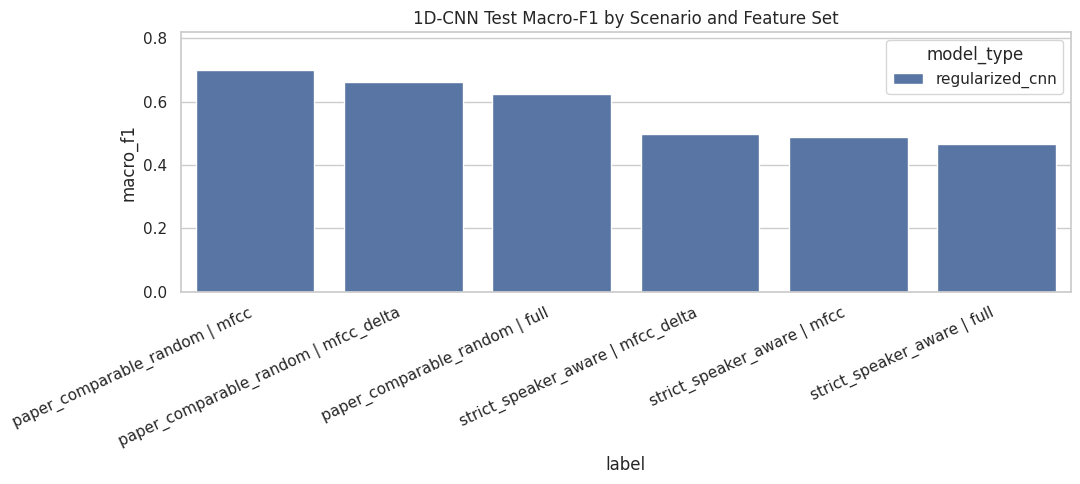

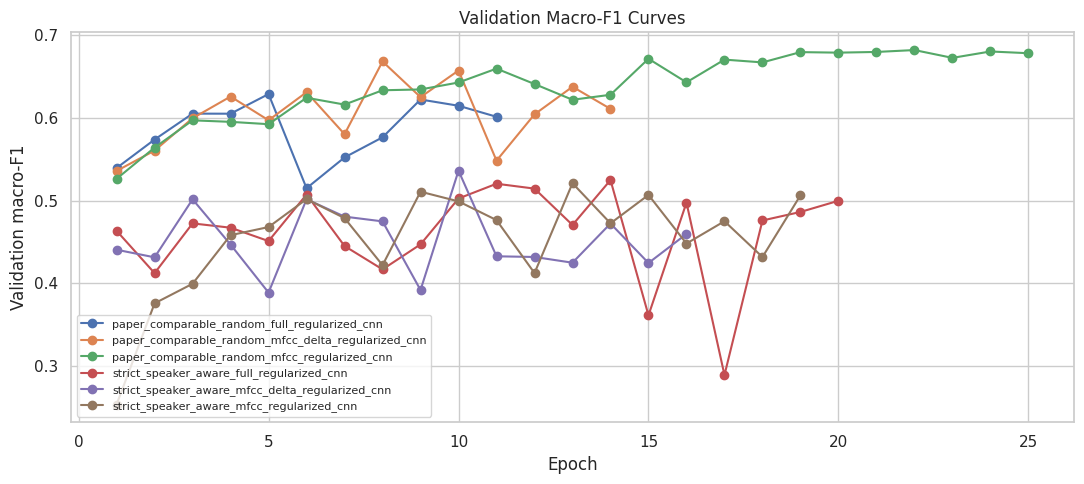

,run_suite,run_group,scenario,run_name,model_type,feature_name,split,n_samples,loss,accuracy,macro_f1,weighted_f1,inference_time_sec,inference_ms_per_sample,macro_precision,macro_recall,best_epoch,best_val_macro_f1,train_time_sec,selection_rule
0,single,Run 2 - feature ablation,paper_comparable_random,paper_comparable_random_mfcc_regularized_cnn,regularized_cnn,mfcc,test,1698,0.857488,0.697880,0.698569,0.698085,0.179329,0.105612,0.700335,0.698832,22,0.681725,75.858566,selected_by_validation_macro_f1
4,single,Run 2 - feature ablation,strict_speaker_aware,strict_speaker_aware_mfcc_delta_regularized_cnn,regularized_cnn,mfcc_delta,test,1953,1.477536,0.508961,0.496744,0.496124,0.339102,0.173631,0.517663,0.512627,10,0.536036,69.050054,selected_by_validation_macro_f1


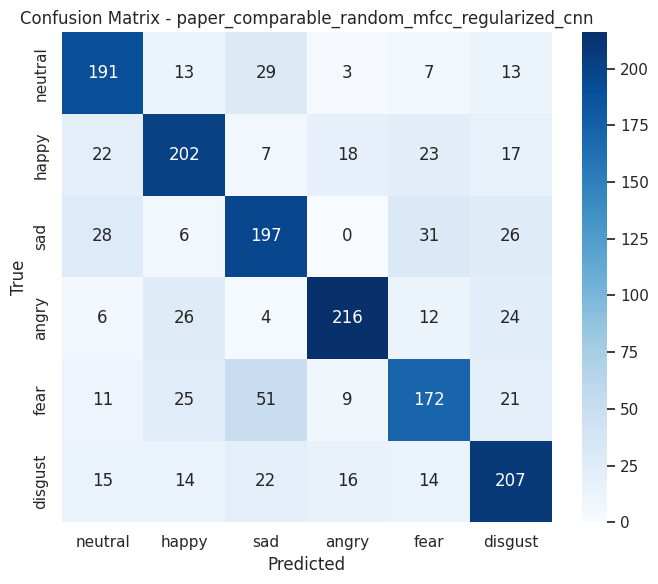

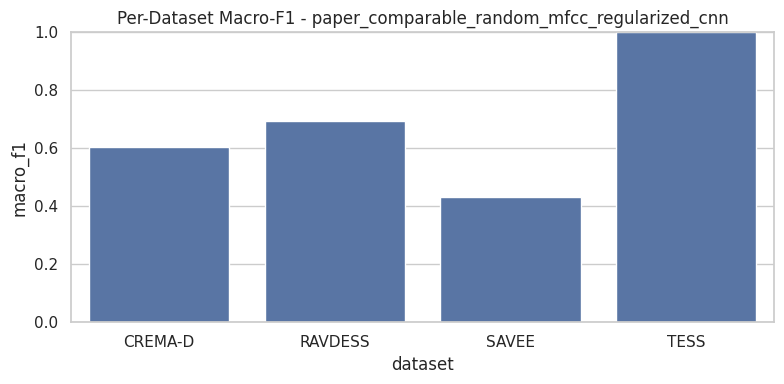

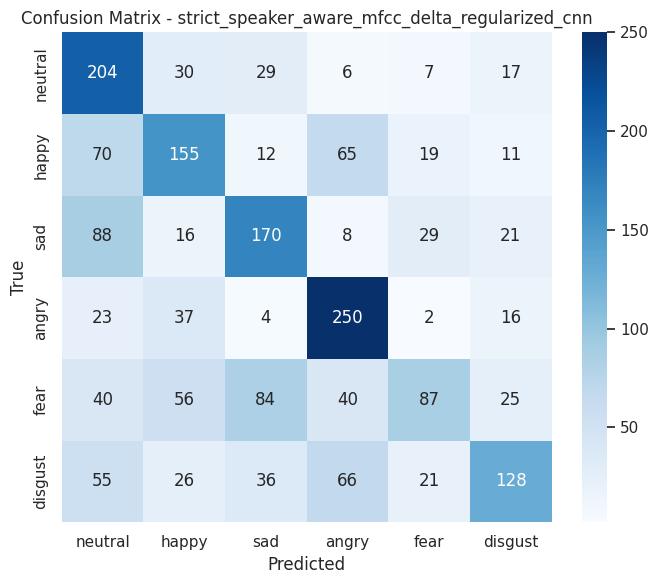

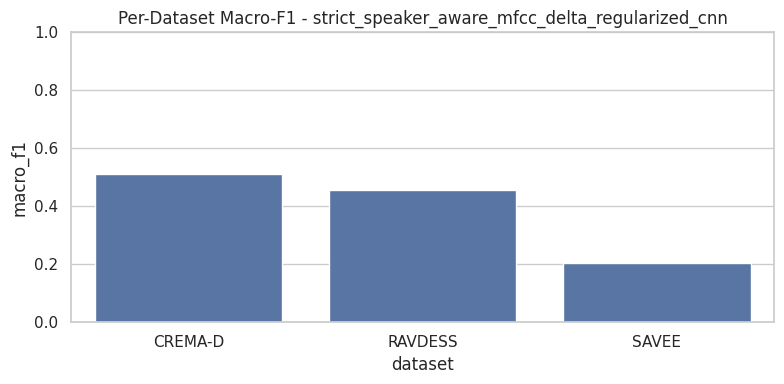

In [10]:
if not metrics_df.empty:
    plot_df = metrics_df.copy(); plot_df['label'] = plot_df['scenario'] + ' | ' + plot_df['feature_name']
    plt.figure(figsize=(11, 5)); sns.barplot(data=plot_df, x='label', y='macro_f1', hue='model_type'); plt.xticks(rotation=25, ha='right'); plt.ylim(0, max(0.1, min(1.0, plot_df['macro_f1'].max() + 0.12))); plt.title('1D-CNN Test Macro-F1 by Scenario and Feature Set'); plt.tight_layout(); plt.savefig(FIGURE_DIR / 'cnn1d_test_macro_f1.png', dpi=160); plt.show()
if not history_df.empty:
    plt.figure(figsize=(11, 5))
    for run_name, group in history_df.groupby('run_name'): plt.plot(group['epoch'], group['val_macro_f1'], marker='o', label=run_name)
    plt.xlabel('Epoch'); plt.ylabel('Validation macro-F1'); plt.title('Validation Macro-F1 Curves'); plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIGURE_DIR / 'cnn1d_validation_curves.png', dpi=160); plt.show()
best_df = metrics_df.sort_values(['scenario', 'best_val_macro_f1', 'macro_f1'], ascending=[True, False, False]).groupby('scenario', as_index=False).head(1)
best_df['selection_rule'] = 'selected_by_validation_macro_f1'
best_df.to_csv(REPORT_DIR / 'cnn1d_best_models_summary.csv', index=False)
display(best_df)
for _, row in best_df.iterrows():
    run_name = row['run_name']; pred_df = pd.read_csv(PRED_DIR / f'predictions_{run_name}.csv'); cm = confusion_matrix(pred_df['y_true'], pred_df['y_pred'], labels=list(range(len(COMMON_EMOTIONS))))
    plt.figure(figsize=(7, 6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS); plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion Matrix - {run_name}'); plt.tight_layout(); plt.savefig(FIGURE_DIR / f'confusion_matrix_{run_name}.png', dpi=160); plt.show()
    ds_df = per_dataset_df[per_dataset_df['run_name'] == run_name]
    if not ds_df.empty:
        plt.figure(figsize=(8, 4)); sns.barplot(data=ds_df, x='dataset', y='macro_f1'); plt.ylim(0, 1.0); plt.title(f'Per-Dataset Macro-F1 - {run_name}'); plt.tight_layout(); plt.savefig(FIGURE_DIR / f'per_dataset_macro_f1_{run_name}.png', dpi=160); plt.show()

## 10.1. Full Suite Summary Tables

Các bảng này phục vụ Run 4: chọn model theo validation macro-F1, so sánh test macro-F1, accuracy và inference time. Nếu chạy `RUN_SUITE=full_4run`, đây là phần quan trọng nhất để đưa vào report.

,scenario,run_group,model_type,feature_name,run_name,best_val_macro_f1,macro_f1,accuracy,weighted_f1,inference_ms_per_sample,best_epoch,train_time_sec
0,paper_comparable_random,Run 2 - feature ablation,regularized_cnn,mfcc,paper_comparable_random_mfcc_regularized_cnn,0.681725,0.698569,0.697880,0.698085,0.105612,22,75.858566
1,paper_comparable_random,Run 2 - feature ablation,regularized_cnn,mfcc_delta,paper_comparable_random_mfcc_delta_regularized...,0.667931,0.662813,0.664311,0.662957,0.161419,8,63.487043
2,paper_comparable_random,Run 2 - feature ablation,regularized_cnn,full,paper_comparable_random_full_regularized_cnn,0.628567,0.624635,0.627797,0.623780,0.277492,5,74.574841
3,strict_speaker_aware,Run 2 - feature ablation,regularized_cnn,mfcc_delta,strict_speaker_aware_mfcc_delta_regularized_cnn,0.536036,0.496744,0.508961,0.496124,0.173631,10,69.050054
4,strict_speaker_aware,Run 2 - feature ablation,regularized_cnn,full,strict_speaker_aware_full_regularized_cnn,0.524715,0.465675,0.475678,0.464938,0.298849,14,132.224803
5,strict_speaker_aware,Run 2 - feature ablation,regularized_cnn,mfcc,strict_speaker_aware_mfcc_regularized_cnn,0.520888,0.489703,0.492576,0.489876,0.120665,13,50.775641


,scenario,feature_name,accuracy,best_val_macro_f1,inference_ms_per_sample,macro_f1
1,paper_comparable_random,mfcc,0.697880,0.681725,0.105612,0.698569
2,paper_comparable_random,mfcc_delta,0.664311,0.667931,0.161419,0.662813
0,paper_comparable_random,full,0.627797,0.628567,0.277492,0.624635
5,strict_speaker_aware,mfcc_delta,0.508961,0.536036,0.173631,0.496744
3,strict_speaker_aware,full,0.475678,0.524715,0.298849,0.465675
4,strict_speaker_aware,mfcc,0.492576,0.520888,0.120665,0.489703


,scenario,model_type,feature_name,best_val_macro_f1,macro_f1,accuracy,inference_ms_per_sample,best_epoch
2,paper_comparable_random,regularized_cnn,full,0.628567,0.624635,0.627797,0.277492,5
5,strict_speaker_aware,regularized_cnn,full,0.524715,0.465675,0.475678,0.298849,14


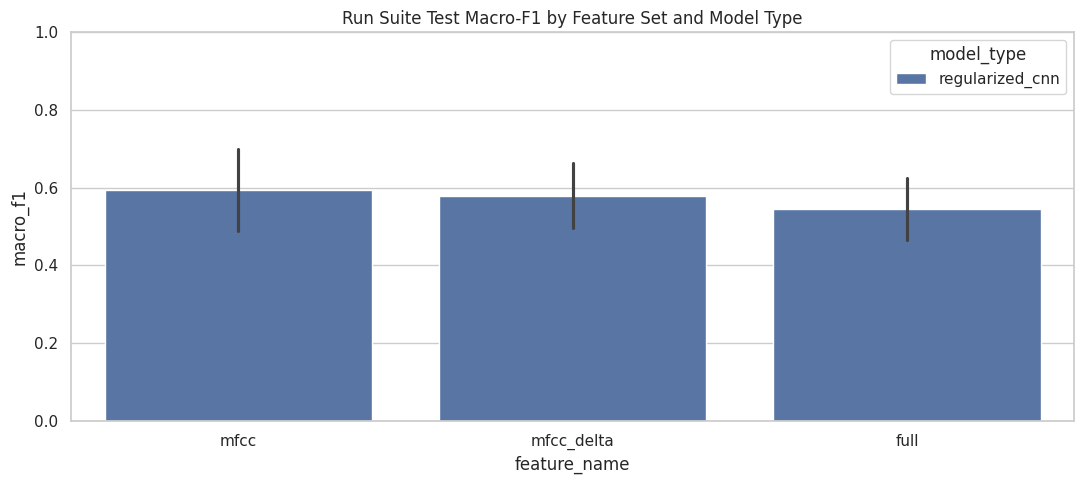

In [11]:
leaderboard_cols = ['scenario', 'run_group', 'model_type', 'feature_name', 'run_name', 'best_val_macro_f1', 'macro_f1', 'accuracy', 'weighted_f1', 'inference_ms_per_sample', 'best_epoch', 'train_time_sec']
leaderboard_df = metrics_df[leaderboard_cols].sort_values(['scenario', 'best_val_macro_f1', 'macro_f1'], ascending=[True, False, False]).reset_index(drop=True)
leaderboard_df.to_csv(REPORT_DIR / 'run_suite_leaderboard.csv', index=False)
display(leaderboard_df)

ablation_df = metrics_df[metrics_df['model_type'] == 'regularized_cnn'].copy()
ablation_table = ablation_df.pivot_table(index=['scenario', 'feature_name'], values=['best_val_macro_f1', 'macro_f1', 'accuracy', 'inference_ms_per_sample'], aggfunc='first').reset_index()
ablation_table = ablation_table.sort_values(['scenario', 'best_val_macro_f1'], ascending=[True, False])
ablation_table.to_csv(REPORT_DIR / 'feature_ablation_summary.csv', index=False)
display(ablation_table)

attention_table = metrics_df[(metrics_df['feature_name'] == 'full') & (metrics_df['model_type'].isin(['regularized_cnn', 'attention_cnn']))].copy()
attention_table = attention_table[['scenario', 'model_type', 'feature_name', 'best_val_macro_f1', 'macro_f1', 'accuracy', 'inference_ms_per_sample', 'best_epoch']]
attention_table = attention_table.sort_values(['scenario', 'best_val_macro_f1'], ascending=[True, False])
attention_table.to_csv(REPORT_DIR / 'attention_vs_regular_summary.csv', index=False)
display(attention_table)

plt.figure(figsize=(11, 5))
sns.barplot(data=leaderboard_df, x='feature_name', y='macro_f1', hue='model_type')
plt.title('Run Suite Test Macro-F1 by Feature Set and Model Type')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'run_suite_macro_f1_by_feature_model.png', dpi=160)
plt.show()

## 11. Compare with Notebook 04 Baseline

| Scenario | Best 04 model | Accuracy | Macro-F1 |
|---|---|---:|---:|
| paper_comparable_random | SVM RBF tuned | 66.61% | 66.64% |
| strict_speaker_aware | Probability-average ensemble | 47.06% | 46.53% |

,scenario,model_family,model,accuracy,macro_f1
0,paper_comparable_random,04 classical baseline,SVM RBF tuned,0.666100,0.666400
1,strict_speaker_aware,04 classical baseline,Probability-average ensemble,0.470600,0.465300
2,paper_comparable_random,05 1D-CNN,paper_comparable_random_mfcc_regularized_cnn,0.697880,0.698569
3,strict_speaker_aware,05 1D-CNN,strict_speaker_aware_mfcc_delta_regularized_cnn,0.508961,0.496744


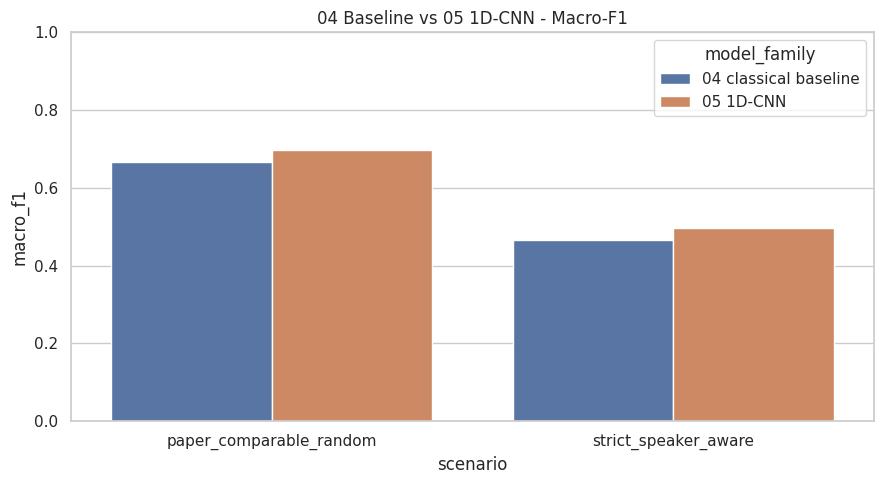

In [12]:
baseline_04 = pd.DataFrame([{'scenario': 'paper_comparable_random', 'model_family': '04 classical baseline', 'model': 'SVM RBF tuned', 'accuracy': 0.6661, 'macro_f1': 0.6664}, {'scenario': 'strict_speaker_aware', 'model_family': '04 classical baseline', 'model': 'Probability-average ensemble', 'accuracy': 0.4706, 'macro_f1': 0.4653}])
cnn_best = best_df.rename(columns={'run_name': 'model'}).copy(); cnn_best['model_family'] = '05 1D-CNN'
comparison_df = pd.concat([baseline_04, cnn_best[['scenario', 'model_family', 'model', 'accuracy', 'macro_f1']]], ignore_index=True)
comparison_df.to_csv(REPORT_DIR / 'baseline04_vs_cnn1d05.csv', index=False); display(comparison_df)
plt.figure(figsize=(9, 5)); sns.barplot(data=comparison_df, x='scenario', y='macro_f1', hue='model_family'); plt.ylim(0, 1.0); plt.title('04 Baseline vs 05 1D-CNN - Macro-F1'); plt.tight_layout(); plt.savefig(FIGURE_DIR / 'baseline04_vs_cnn1d05_macro_f1.png', dpi=160); plt.show()

## 12. Export Package

Cell này đóng gói output để tải về từ Kaggle.

In [13]:
summary = {'notebook': '05_Main_1D_CNN_SER', 'ser_processed': str(SER_PROCESSED), 'target_sr': TARGET_SR, 'target_duration': TARGET_DURATION, 'max_frames': MAX_FRAMES, 'common_emotions': COMMON_EMOTIONS, 'quick_run': QUICK_RUN, 'best_models': best_df.to_dict(orient='records') if not best_df.empty else []}
with open(REPORT_DIR / 'cnn1d_summary.json', 'w', encoding='utf-8') as f: json.dump(summary, f, ensure_ascii=False, indent=2)
zip_base = OUTPUT_DIR.parent / '05_Main_1D_CNN_SER_results'; zip_path = shutil.make_archive(str(zip_base), 'zip', OUTPUT_DIR)
print('Created zip:', zip_path); print('Output dir:', OUTPUT_DIR)

Created zip: /kaggle/working/05_Main_1D_CNN_SER_results.zip
Output dir: /kaggle/working/05_Main_1D_CNN_SER_outputs


## 13. Notes for Report

> Notebook 05 chuyển từ handcrafted statistical vector sang frame-level acoustic feature sequence. 1D-CNN được dùng để học temporal patterns của cảm xúc trong audio. Kết quả được báo cáo trên cả random split để so với nhiều nghiên cứu trước và strict split để đánh giá generalization nghiêm túc hơn.

Nếu 1D-CNN tốt hơn 04, có thể kết luận temporal representation giúp model học biến thiên cảm xúc tốt hơn mean/std pooling. Nếu chưa tốt hơn, có thể giải thích multi-corpus SER vẫn khó do speaker/domain shift và dùng notebook 06 log-Mel hoặc 07 temporal model làm bước cải thiện tiếp theo.